In [23]:
# Libreries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [24]:
# Loading Dataset
df = pd.read_csv("train.ft.txt", sep="\t", header=None)

# reschape into two colummns
df.columns = ["raw"]
df["label"] = df["raw"].apply(lambda x: x.split(" ")[0])
df["text"] = df["raw"].apply(lambda x: " ".join(x.split(" ")[1:]))
df=df.drop("raw", axis=1)
print(df.head())

        label                                               text
0  __label__2  Stuning even for the non-gamer: This sound tra...
1  __label__2  The best soundtrack ever to anything.: I'm rea...
2  __label__2  Amazing!: This soundtrack is my favorite music...
3  __label__2  Excellent Soundtrack: I truly like this soundt...
4  __label__2  Remember, Pull Your Jaw Off The Floor After He...


In [25]:
df.label.value_counts()

label
__label__2    1800000
__label__1    1800000
Name: count, dtype: int64

In [26]:
# replacing categorical Data into numerical
df['label']=df.label.map({"__label__1":0,"__label__2":1})
print(df.head())

   label                                               text
0      1  Stuning even for the non-gamer: This sound tra...
1      1  The best soundtrack ever to anything.: I'm rea...
2      1  Amazing!: This soundtrack is my favorite music...
3      1  Excellent Soundtrack: I truly like this soundt...
4      1  Remember, Pull Your Jaw Off The Floor After He...


The labels are converted as follows: label 0 = negative, label 1 = positive

In [27]:
df.label.value_counts()

label
1    1800000
0    1800000
Name: count, dtype: int64

In [28]:
# Basic information

print('The Shape of the Data: ', df.shape)
print('\nThe coloumns of the data:\n ', df.columns.to_list())
print('\nThe Data Type:\n ', df.dtypes.value_counts())

The Shape of the Data:  (3600000, 2)

The coloumns of the data:
  ['label', 'text']

The Data Type:
  int64     1
object    1
Name: count, dtype: int64


In [29]:
# Check missing values
df.isna().sum()

label    0
text     0
dtype: int64

In [30]:
# Subset from Dataset
df = df.sample(30000, random_state=42)
print(df.shape)
print(df.label.value_counts())

(30000, 2)
label
1    15015
0    14985
Name: count, dtype: int64


In [31]:
# checking dublicates
df.duplicated().sum()

np.int64(0)

There are no dublicates in Dataset

<h1>Text Cleaning</h1>

In [32]:
# putting all leters in lowercase

df['text'] = df['text'].str.lower()
print(df['text'].head(3))

2079998    expensive junk: this product consists of a pie...
1443106    toast too dark: even on the lowest setting, th...
3463669    excellent imagery...dumbed down story: i enjoy...
Name: text, dtype: object


In [33]:
#Creating copy of raw dataset for comparisom text ofter removing punktuation, stopwords and text after lemmatisation.
df_p = df.copy() # dataset with text after removing punrtuation
df_stp = df.copy() # dataset with text after remoing stopwords
df_lemma = df.copy() # data set with text after lemmatisation


In [34]:
# Calculating the Lengrth of texts

df['length'] = df['text'].apply(lambda x: len(str(x).split()))
print(df.head(2))

         label                                               text  length
2079998      0  expensive junk: this product consists of a pie...     101
1443106      0  toast too dark: even on the lowest setting, th...      39


In [43]:
df.describe()

,label,length
count,30000.000000,30000.000000
mean,0.500500,78.371467
std,0.500008,42.750195
min,0.000000,13.000000
25%,0.000000,42.000000
50%,1.000000,70.000000
75%,1.000000,108.000000
max,1.000000,210.000000


In [44]:
# Rempoving all punctuation and adding text length

df_p['length'] = df_p['text'].apply(lambda x: len(str(x).split()))
print(df_p.head(2)) 
df_p['text']=df_p['text'].str.replace(r'[^\w\s]', '', regex=True)
print(df_p['text'].head(2))

# check if any punctuation is still in text
print(df_p['text'].str.contains(r'[^\w\s]', regex=True, na=False).any())

         label                                               text  length
2079998      0  expensive junk: this product consists of a pie...     101
1443106      0  toast too dark: even on the lowest setting, th...      39
2079998    expensive junk this product consists of a piec...
1443106    toast too dark even on the lowest setting the ...
Name: text, dtype: object
False


As a result, the text is converted to lowercase and all punctuation is removed.

In [45]:
df_p.describe()

,label,length
count,30000.000000,30000.000000
mean,0.500500,78.371467
std,0.500008,42.750195
min,0.000000,13.000000
25%,0.000000,42.000000
50%,1.000000,70.000000
75%,1.000000,108.000000
max,1.000000,210.000000


In [46]:
df_p['label'].value_counts()

label
1    15015
0    14985
Name: count, dtype: int64

In [47]:
df_p.isna().sum()

label     0
text      0
length    0
dtype: int64

In [48]:
# DataFrame after lemmatization
import nltk

# Load English language model (only components needed for lemmatization)
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmas = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmas)

# Apply lemmatization and remove non-informative tokens
df_lemma["text"] = df_lemma["text"].apply(lemmatize_text)

df_lemma['length'] = df_lemma['text'].apply(lambda x: len(str(x).split()))

# Display first rows
print(df_lemma.head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ritap\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ritap\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


         label                                               text  length
2079998      0  expensive junk: this product consists of a pie...     101
1443106      0  toast too dark: even on the lowest setting, th...      39
3463669      1  excellent imagery...dumbed down story: i enjoy...      70
2914699      0  are we pretending everyone is married?: the au...      65
1603231      0  not worth your time: might a well just use a k...      25


Text after lemmatization contains words in their base form. Only for English language.

In [49]:
df_lemma.describe()

,label,length
count,30000.000000,30000.000000
mean,0.500500,78.371467
std,0.500008,42.750195
min,0.000000,13.000000
25%,0.000000,42.000000
50%,1.000000,70.000000
75%,1.000000,108.000000
max,1.000000,210.000000


In [50]:
df_lemma.isna().sum()

label     0
text      0
length    0
dtype: int64

In [52]:
# DataFrame after stopword removal
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered)

df_stp["text"] = df_stp["text"].apply(remove_stopwords)

# text length
df_stp["length"] = df_stp["text"].apply(lambda x: len(str(x).split()))

# Display first rows
print(df_stp.head())



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ritap\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


         label                                               text  length
2079998      0  expensive junk: product consists piece thin fl...      56
1443106      0  toast dark: even lowest setting, toast dark li...      19
3463669      1  excellent imagery...dumbed story: enjoyed disc...      39
2914699      0  pretending everyone married?: authors pretend ...      37
1603231      0  worth time: might well use knife, product hold...      13


Text after lemmatization  and stopword removal contains omly important words in their base form. Only for English language.

In [53]:
df_stp.describe()

,label,length
count,30000.000000,30000.000000
mean,0.500500,41.511967
std,0.500008,22.623110
min,0.000000,7.000000
25%,0.000000,23.000000
50%,1.000000,37.000000
75%,1.000000,57.000000
max,1.000000,158.000000


In [54]:
df_stp.isna().sum()

label     0
text      0
length    0
dtype: int64

In [55]:
# Balance Analysing
df_stp.label.value_counts()

label
1    15015
0    14985
Name: count, dtype: int64

The class distribution is approximately balanced in all datasets, with a ratio close to 50/50.

<h1>EDA</h1>

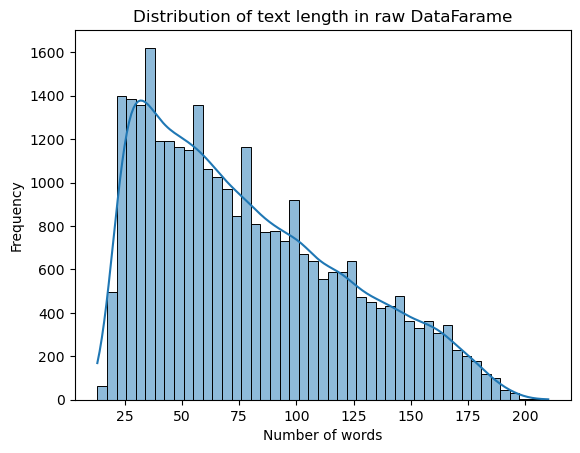

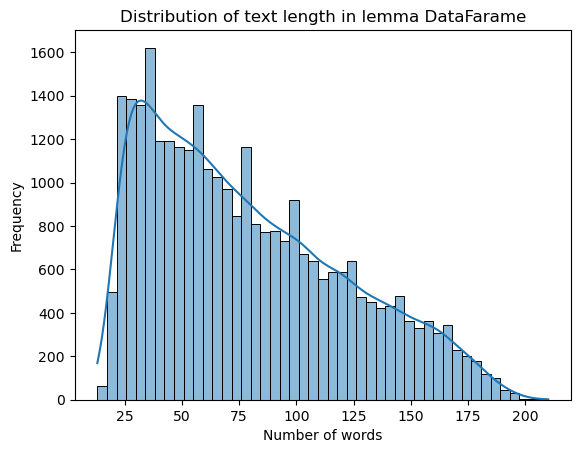

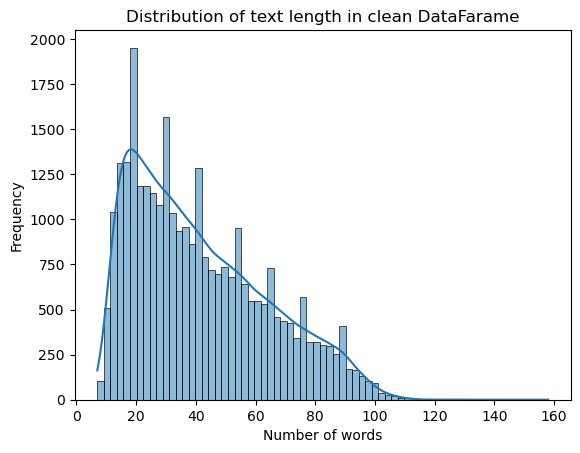

In [56]:
#destribution of words length amont 3 datasets

# creating a lists of dataframes
all_df = [df, df_lemma, df_stp]
names = ["raw", "lemma", "clean"]

#histogramm for all DFs

for d, name in zip(all_df, names):
    sns.histplot(x="length", data = d, kde=True)
    plt.title(f"Distribution of text length in {name} DataFarame")
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.show()



There is no difference between the raw text and the text after lemmatization. On the other hand, the distribution of text length in the dataset after lemmatization and stopword removal looks different. The observed changes in text length distribution may have a positive impact on model performance. By removing stopwords, irrelevant and redundant information is reduced, allowing the model to focus on more meaningful features.

In all cases the distribution exhibits positive skewness, indicating that most texts are relatively short, while a smaller number of texts are significantly longer.

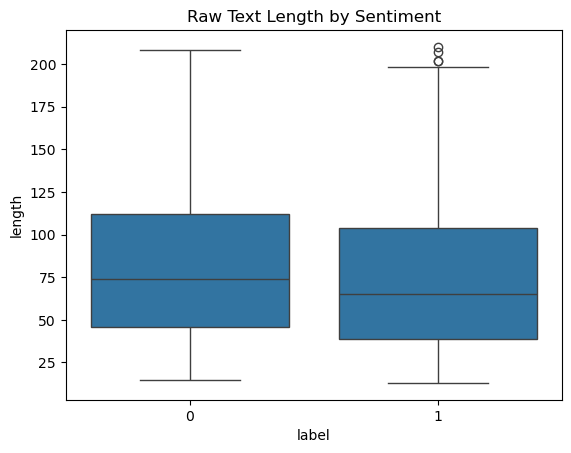

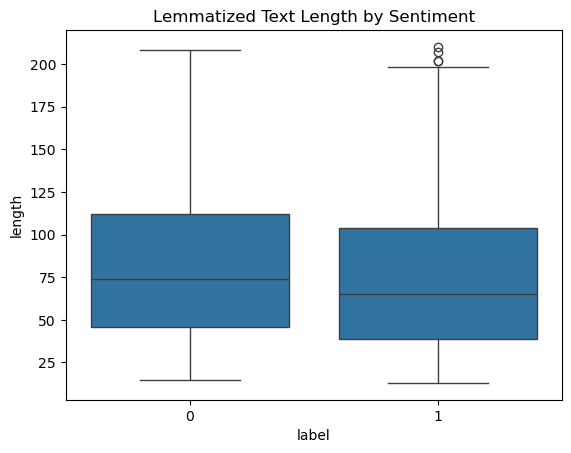

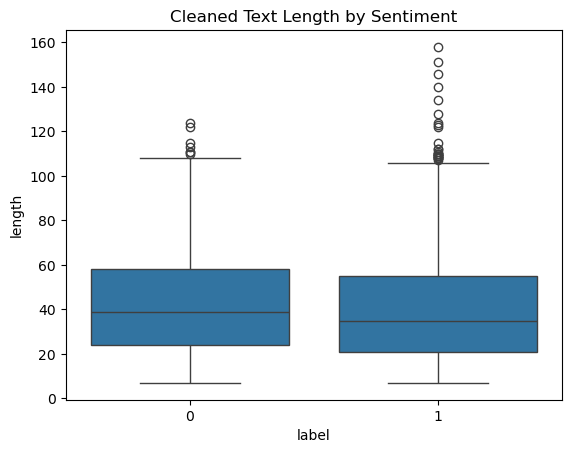

In [58]:
# Destribution of length by labels

datasets = [df, df_lemma, df_stp]
names = ['Raw', 'Lemmatized', 'Cleaned']

for df, name in zip(datasets, names):
    sns.boxplot(x='label', y='length', data=df)
    plt.title(f"{name} Text Length by Sentiment")
    plt.show()

The distribution of text length shows that there are almost no outliers in the raw text. In the lemmatized text, there are slightly more outliers. However, in the cleaned text, a larger number of outliers can be observed. This indicates that the preprocessing steps, particularly stopword removal, significantly change the distribution of text length.

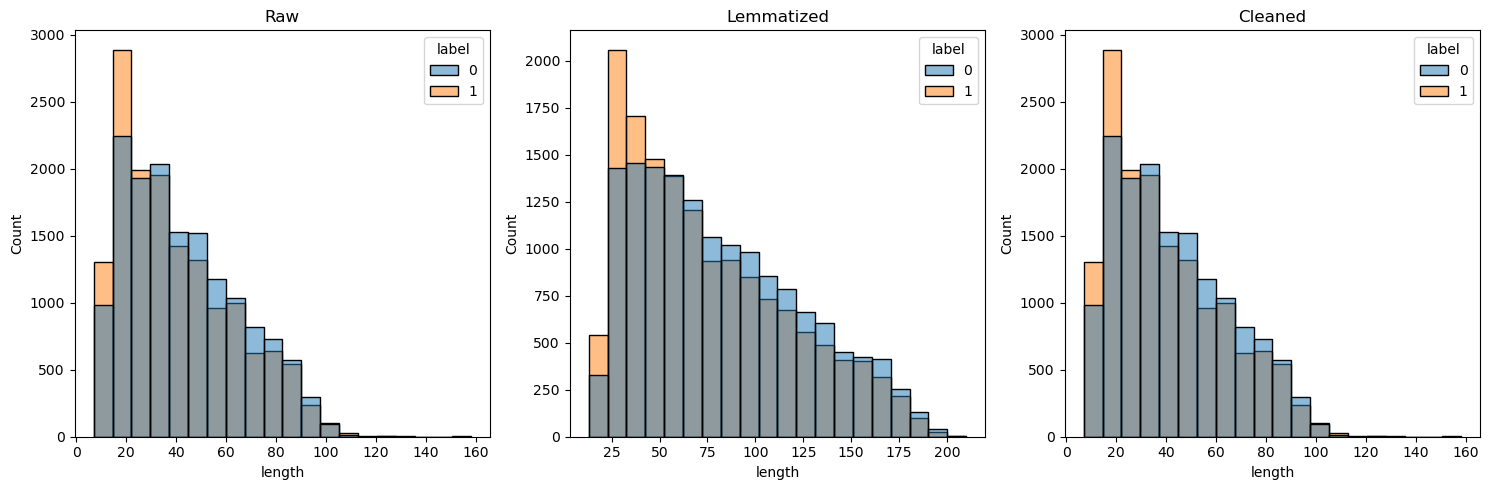

In [59]:
# Comparisong Destribution 

datasets = [df, df_lemma, df_stp]
names = ['Raw', 'Lemmatized', 'Cleaned']

plt.figure(figsize=(15,5))

for i, (df, name) in enumerate(zip(datasets, names), 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x='length', hue='label', bins=20)
    plt.title(name)

plt.tight_layout()
plt.show()
 
    

The distributions show differences in text length between positive and negative reviews.

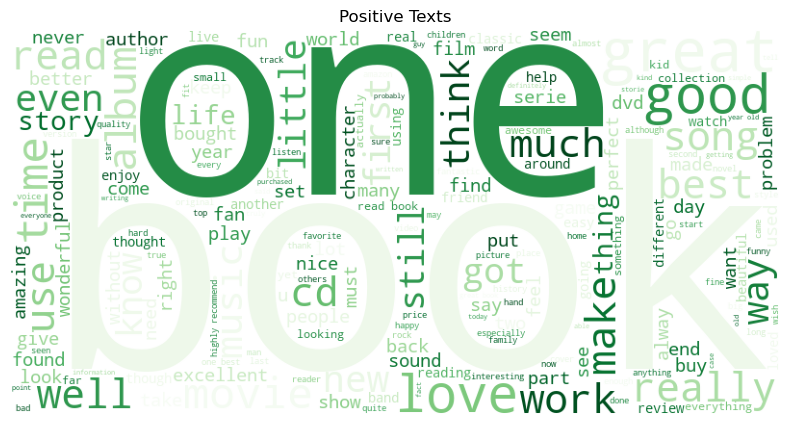

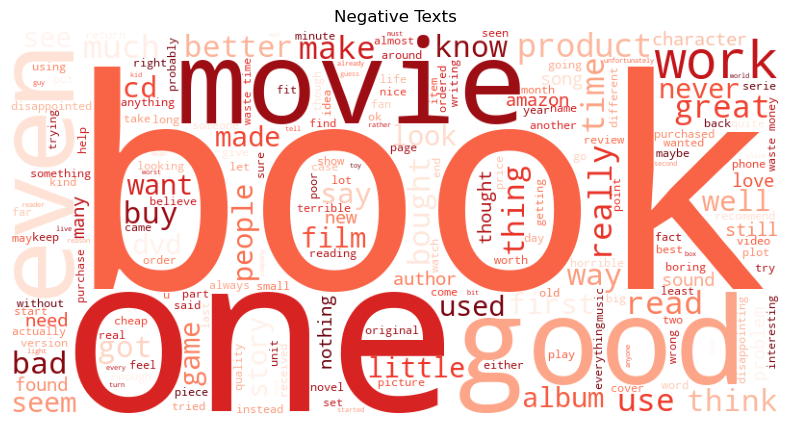

In [60]:
# Building WordCloud
from wordcloud import WordCloud
from wordcloud import STOPWORDS

# dшviding positive and negative feedback
positive = " ".join(df_stp[df_stp['label']==1]['text'])
negative = " ".join(df_stp[df_stp['label']==0]['text'])

wc_pos = WordCloud(colormap="Greens", 
                   background_color="white", 
                   width=800,
                   height=400,
                   max_words=200,
                   stopwords=STOPWORDS)

wc_neg = WordCloud(colormap="Reds", 
                   background_color="white",
                   width=800,
                   height=400,
                   max_words=200,
                   stopwords=STOPWORDS)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos.generate(positive))
plt.axis("off")
plt.title("Positive Texts")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(wc_neg.generate(negative))
plt.axis("off")
plt.title("Negative Texts")
plt.show()


The WordCloud visualisation shows the most frequent wotds in both negative and positive reviews.

In [61]:
# Analysing most common words
from collections import Counter

label = df_stp['label'].unique()
r =[]
for g in label:
    text = ' '.join(df_stp[df_stp['label'] == g]['text'])
    w = text.split()
    counter = Counter(w)
    most_com = counter.most_common(10)
    for w, freq in most_com:
        r.append({
            "label": g,
            "word": w,
            "frequency": freq
        })
df_com = pd.DataFrame(r)
print(df_com)

    label    word  frequency
0       0    book       5382
1       0     one       4760
2       0   would       4416
3       0    like       4259
4       0     get       3187
5       0    good       2914
6       0    even       2652
7       0  really       2293
8       0     it.       2200
9       0     buy       2155
10      1    book       6079
11      1   great       5825
12      1     one       4691
13      1    good       4169
14      1    like       3690
15      1    love       2814
16      1   would       2660
17      1  really       2437
18      1     get       2359
19      1    read       2347


The most common words for each label are displayed in descending order of frequency. For negative texts, the most frequent words include "not", "book", "buy", and "like". For positive texts, the most common words are "book", "good", "great", "not", "like", and "love". 

It is noteworthy that some words, such as "not", appear in both classes, but their frequency and contextual usage differ.

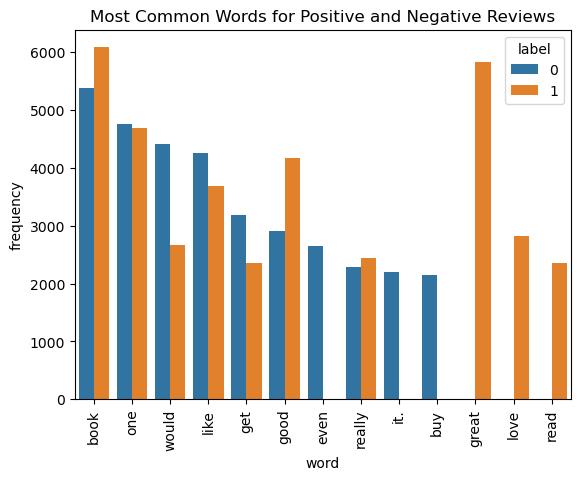

In [62]:
# Visualisation of most common words

sns.barplot(x='word', y='frequency', data=df_com, hue='label')
plt.title("Most Common Words for Positive and Negative Reviews")
plt.xticks(rotation=90)
plt.show()

The analysis of the most frequent words reveals clear differences between sentiment classes. Positive reviews are characterized by words such as "good", "great", and "love", which reflect satisfaction and a positive user experience. In contrast, negative reviews contain words such as "would", "one", and "like", which may indicate dissatisfaction or criticism.

It is also noteworthy that some words, such as "book" and "one" etc., appear frequently in both classes, suggesting that certain terms are domain-specific rather than sentiment-specific.

This indicates that not all frequent words are equally informative for sentiment classification, highlighting the importance of feature selection techniques such as TF-IDF.

In [36]:
# Analysis of Pharases

# Basic n-gramm extraction for raw text

from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, ngram_range=(2,2), n=15):
    vec = CountVectorizer(
        ngram_range=ngram_range,
        min_df=3                                 # using pharases that are in more than 3 texts
    )
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    return pd.Series(freqs, index=vec.get_feature_names_out()) \
             .sort_values(ascending=False) \
             .head(n)

neg_ngrams = get_top_ngrams(
    df_stp[df_stp.label==0]["text"])

pos_ngrams = get_top_ngrams(
    df_stp[df_stp.label==1]["text"])

# phrase-level stylistic differences.
df_ngrams = pd.concat(
    [neg_ngrams.rename("Negative"),
     pos_ngrams.rename("Positive")],
    axis=1
).fillna(0)

print(df_ngrams)

           Negative  Positive
of the       5986.0    6139.0
in the       3744.0    3360.0
this book    3636.0    3808.0
it is        2653.0    2997.0
if you       2577.0    2437.0
it was       2516.0    1624.0
and the      2313.0    2401.0
this is      2308.0    3346.0
on the       2301.0    2021.0
to be        2282.0       0.0
to the       2153.0    1942.0
for the      1832.0    1892.0
the book     1765.0    1572.0
is not       1571.0       0.0
with the     1521.0       0.0
one of          0.0    1729.0
the best        0.0    1685.0
is the          0.0    1562.0


The parameter ngram_range = (2,2) enables the extraction of bigrams, allowing the analysis of word combinations rather than individual terms.

The neutral term "book" in positive reviews is often combined with words such as "love", "great", "good", and "read", highlighting positive customer opinions.

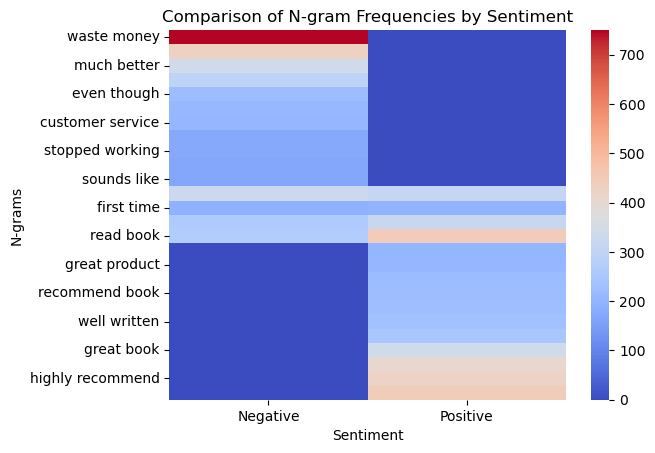

In [64]:
# Heatmap for n-grams

df_ngrams['diff'] = df_ngrams['Negative'] - df_ngrams['Positive']
df_ngrams = df_ngrams.sort_values('diff', ascending=False).drop(columns='diff')

sns.heatmap(df_ngrams, cmap="coolwarm")
plt.title("Comparison of N-gram Frequencies by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("N-grams")
plt.show()

The heatmap illustrates differences in the frequency of n-grams between positive and negative reviews.

# Modellierung

In [37]:
# Bag of Words

bow= CountVectorizer(
    ngram_range=(1,2), 
    stop_words='english',
    max_features=5000
)

Bag-of-Words is a text representation method that encodes documents as vectors of word frequencies while ignoring word order and syntactic structure.

In [38]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    stop_words='english',
    min_df=5,
    max_df=1.0
)

TF-IDF is a vectorization method that weights words by their importance within a document relative to their frequency across the corpus, emphasizing discriminative terms while down-weighting common ones.

In [39]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Using the same indices for fair comparison across datasets
train_idx = X_train.index
test_idx = X_test.index

X_train_p = df_p.loc[train_idx, "text"]
X_test_p  = df_p.loc[test_idx, "text"]

X_train_lemma = df_lemma.loc[train_idx, "text"]
X_test_lemma  = df_lemma.loc[test_idx, "text"]

X_train_stp = df_stp.loc[train_idx, "text"]
X_test_stp  = df_stp.loc[test_idx, "text"]

To ensure a fair comparison between different preprocessing methods, the same train-test split is applied across all datasets.

## Pipelines

In [40]:
# Libraries
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn import set_config
set_config(display='diagram')

#### Lagistic Regression

In [41]:
#logistic Regression + TF-Idf 
lr_tf = Pipeline(steps=[
    ('tfidf', tfidf),
    ('model', LogisticRegression(max_iter=1000))
])


In [42]:
#logistic Regression + Bag of Words 
lr_bow = Pipeline(steps=[
    ('bow', bow),
    ('model', LogisticRegression(max_iter=1000))
])

Two pipelines are developed to compare TF-IDF and Bag-of-Words representations using Logistic Regression.

In [43]:
lr_tf

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [44]:
lr_bow

,steps,"[('bow', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [45]:
#Function for model evaluation
from sklearn.base import clone

results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, name, dataset_name):
    
    model = clone(model)  # 🔥cloning the model to except further rrrors
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except:
        roc = None
    
    results.append({
        "Dataset": dataset_name,
        "Model": name,
        "Accuracy": acc,
        "ROC_AUC": roc,
        "F1_score": f1,
        "Precision": precision,
        "Recall": recall
    })
    
    print(f"\n{name} | {dataset_name}")
    print("Accuracy:", round(acc,4))
    if roc:
        print("ROC AUC:", round(roc,4))
    print(classification_report(y_test, y_pred))
  #  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
 #   plt.show()

# Datasets
datasets = {
    "raw": (X_train, X_test),
    "no_punctuation": (X_train_p, X_test_p),
    "lemma": (X_train_lemma, X_test_lemma),
    "no_stopwords": (X_train_stp, X_test_stp)
}

# Models

models = { "LogReg_TFIDF": lr_tf,
           "LogReg_BOW": lr_bow}

for data_name, (X_tr, X_te) in datasets.items():
    for model_name, model in models.items():
        evaluate_model(model, X_tr, X_te, y_train, y_test, model_name, data_name)





LogReg_TFIDF | raw
Accuracy: 0.8562
ROC AUC: 0.9365
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      2997
           1       0.85      0.87      0.86      3003

    accuracy                           0.86      6000
   macro avg       0.86      0.86      0.86      6000
weighted avg       0.86      0.86      0.86      6000


LogReg_BOW | raw
Accuracy: 0.843
ROC AUC: 0.9231
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      2997
           1       0.83      0.87      0.85      3003

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000


LogReg_TFIDF | no_punctuation
Accuracy: 0.8562
ROC AUC: 0.9365
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      2997
           1       0.85      0.87      0.86      3003

    accuracy   

In [88]:
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Accuracy", ascending = False))

          Dataset         Model  Accuracy   ROC_AUC  F1_score  Precision  \
0             raw  LogReg_TFIDF  0.857333  0.934223  0.859488   0.847523   
6    no_stopwords  LogReg_TFIDF  0.857333  0.934223  0.859488   0.847523   
2  no_punctuation  LogReg_TFIDF  0.855333  0.935788  0.857798   0.844244   
3  no_punctuation    LogReg_BOW  0.853167  0.923982  0.856163   0.839846   
4           lemma  LogReg_TFIDF  0.853000  0.935236  0.855030   0.844206   
1             raw    LogReg_BOW  0.843167  0.922515  0.847166   0.826886   
7    no_stopwords    LogReg_BOW  0.843167  0.922515  0.847166   0.826886   
5           lemma    LogReg_BOW  0.842000  0.922542  0.845199   0.829221   

     Recall  
0  0.871795  
6  0.871795  
2  0.871795  
3  0.873127  
4  0.866134  
1  0.868465  
7  0.868465  
5  0.861805  


The results indicate that using raw text without additional preprocessing and text after removing stopwords lead to the best model performance.

In addition, TF-IDF outperforms the Bag-of-Words approach. This can be explained by the fact that TF-IDF assigns weights to words based on their importance, reducing the impact of common terms while emphasizing more discriminative features. As a result, it provides a more effective representation for sentiment analysis.

This suggests that excessive preprocessing may remove useful information from the text.

In the following stage, different machine learning models are evaluated using TF-IDF representations based on raw text.

In [91]:
# Naive Bayes + TF-Idf 
nb_tf = Pipeline(steps=[
    ('tfidf', tfidf),
    ('model', MultinomialNB())
])

In [92]:
# XGBoost + TF-IDF 
xgb_tf = Pipeline(steps=[
    ('tfidf', tfidf),
    ('model',  XGBClassifier(n_estimators=200, max_depth=8, random_state=42))
])

In [93]:
# Random Forest + TF-IDF 
rf_tf = Pipeline(steps=[
    ('tfidf', tfidf),
    ('model',  RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))
])

In [94]:
# SVM + TF-IDF 
svm_tf = Pipeline(steps=[
    ('tfidf', tfidf),
    ('model',  LinearSVC(C=1))
])

In [95]:
# Decission Tree + TF-IDF 
dt_tf = Pipeline(steps=[
    ('tfidf', tfidf),
    ('model',  DecisionTreeClassifier(max_depth=6, random_state=42))
])

In [99]:
results_models = []

def evaluate_model_2(model, X_train, X_test, y_train, y_test, name):
    
    model = clone(model)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except:
        roc = None
    
    results_models.append({
        "Model": name,
        "Accuracy": acc,
        "ROC_AUC": roc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
    })
    
    print(f"\n{name} |")
    print("Accuracy:", round(acc,4))
    if roc is not None:
        print("ROC AUC:", round(roc,4))
    print(classification_report(y_test, y_pred))
  #  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
 #   plt.show()

# Models

models = { "LogReg_TFIDF": lr_tf,
           "Naive Bayes": nb_tf,
           "XGBoost": xgb_tf,
           "Random Forest": rf_tf,
           "SVM": svm_tf,
           "Decission Tree": dt_tf,
         }


for model_name, model in models.items():
    evaluate_model_2(model, X_train, X_test, y_train, y_test, model_name)



LogReg_TFIDF |
Accuracy: 0.8573
ROC AUC: 0.9342
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      2997
           1       0.85      0.87      0.86      3003

    accuracy                           0.86      6000
   macro avg       0.86      0.86      0.86      6000
weighted avg       0.86      0.86      0.86      6000


Naive Bayes |
Accuracy: 0.8342
ROC AUC: 0.9138
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2997
           1       0.82      0.85      0.84      3003

    accuracy                           0.83      6000
   macro avg       0.83      0.83      0.83      6000
weighted avg       0.83      0.83      0.83      6000


XGBoost |
Accuracy: 0.8375
ROC AUC: 0.9178
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      2997
           1       0.83      0.85      0.84      3003

    accuracy                           0.

In [100]:
pd.DataFrame(results_models).sort_values(by="Accuracy", ascending = False)

,Model,Accuracy,ROC_AUC,F1,Precision,Recall
0,LogReg_TFIDF,0.857333,0.934223,0.859488,0.847523,0.871795
4,SVM,0.850500,NaN,0.853312,0.838368,0.868798
2,XGBoost,0.837500,0.917843,0.840085,0.827731,0.852814
1,Naive Bayes,0.834167,0.913789,0.837498,0.821795,0.853813
3,Random Forest,0.803833,0.884848,0.814675,0.772700,0.861472
5,Decission Tree,0.681167,0.717141,0.635411,0.742870,0.555112


After comparison all classic Models the best score gives Logistic regression. 

# LLM/GPT

In [128]:
# creatin a short Dataframe

df_gpt = df.sample(1000, random_state=42)

In [129]:
df_gpt["llm_pred"] = None

In [75]:
#!pip install openai

In [76]:
# Connection to API
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path=".env")
print(os.getenv("OPENAI_API_KEY"))
print(os.getcwd())
print("KEY:", os.getenv("OPENAI_API_KEY"))
from openai import OpenAI
client = OpenAI()

None
D:\studium\literatur stud\Case Study
KEY: None


OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

In [137]:
import time

def classify_sentiment(text):
    for _ in range(3):
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-mini",
                messages=[
                    {"role": "system", "content": "Answer ONLY with POSITIVE or NEGATIVE."},
                    {"role": "user", "content": text}
                ],
                temperature=0
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            time.sleep(1)
    return None

In [138]:
# Applying GPT
results = []

for text in df_gpt["text"]:
    try:
        pred = classify_sentiment(text)
        results.append(pred)
    except Exception as e:
        print("Error:", e)
        results.append(None)
    
 #   time.sleep(2)

df_gpt["llm_pred"] = results

In [139]:
df_gpt.head()

,label,text,length,llm_pred
1837867,1,costly worth it: long quit listening sr-60s pa...,48,POSITIVE
706559,0,"ummm... dirty, must take laundry: worst shakir...",58,NEGATIVE
298309,1,"best boook read: wondelful, like lot, begining...",12,POSITIVE
3270044,1,screamfree way be.: book easy reading full gre...,34,POSITIVE
1424181,0,can't make decent romantic comedy?: another id...,59,NEGATIVE


In [140]:
# Converting values into numbers using .map
df_gpt["llm_pred"] = df_gpt["llm_pred"].map({"POSITIVE" : 1, "NEGATIVE" : 0})
print(df_gpt.head())

         label                                               text  length  \
1837867      1  costly worth it: long quit listening sr-60s pa...      48   
706559       0  ummm... dirty, must take laundry: worst shakir...      58   
298309       1  best boook read: wondelful, like lot, begining...      12   
3270044      1  screamfree way be.: book easy reading full gre...      34   
1424181      0  can't make decent romantic comedy?: another id...      59   

         llm_pred  
1837867       1.0  
706559        0.0  
298309        1.0  
3270044       1.0  
1424181       0.0  


In [141]:
# Checking missing values
df_gpt["llm_pred"].isna().sum()

np.int64(1)

In [142]:
df_gpt = df_gpt.dropna(subset=["llm_pred"])
df_gpt["llm_pred"].isna().sum()

np.int64(0)

In [146]:
df_gpt["llm_pred"].astype(int)

1837867    1
706559     0
298309     1
3270044    1
1424181    0
          ..
3285724    0
1695077    1
3389689    1
2333336    0
1697460    0
Name: llm_pred, Length: 999, dtype: int64

In [145]:
df_gpt["llm_pred"].value_counts()

llm_pred
1.0    563
0.0    436
Name: count, dtype: int64

Accuracy: 0.8988988988988988
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       491
           1       0.86      0.95      0.91       508

    accuracy                           0.90       999
   macro avg       0.90      0.90      0.90       999
weighted avg       0.90      0.90      0.90       999



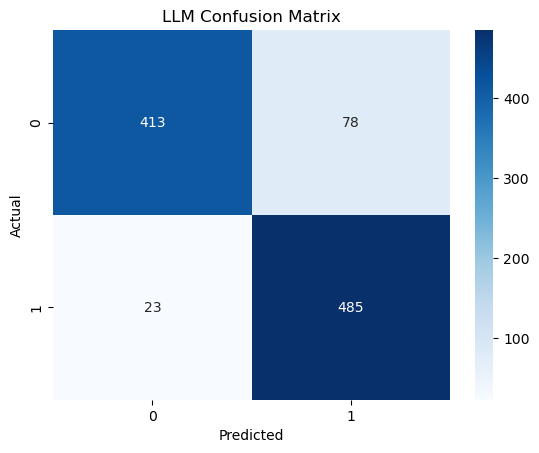

In [147]:
# Accuracy 
acc = accuracy_score(df_gpt["label"], df_gpt["llm_pred"])

cm = confusion_matrix(
    df_gpt["label"],
    df_gpt["llm_pred"]
)

print("Accuracy:", acc)

print(classification_report(df_gpt["label"], df_gpt["llm_pred"]))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LLM Confusion Matrix")
plt.show()

Using the LLM-based approach (GPT), an accuracy of 0.90 was achieved, which is higher than the result obtained with the classical machine learning model (Logistic Regression with TF-IDF).

# Deep Learning

In [150]:
# Vectorisation

tfidf_dl = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    stop_words='english'
)

X_train_vec = tfidf_dl.fit_transform(X_train)
X_test_vec = tfidf_dl.transform(X_test)

In [151]:
# Converting to numpy

X_train_vec = X_train_vec.toarray()
X_test_vec = X_test_vec.toarray()

In [152]:
# Developing model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

dl = Sequential([
    Input(shape=(X_train_vec.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [153]:
# Compilation
dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [154]:
# Fit to the model
dl.fit(
    X_train_vec,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8289 - loss: 0.3799 - val_accuracy: 0.8725 - val_loss: 0.3030
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8986 - loss: 0.2492 - val_accuracy: 0.8571 - val_loss: 0.3226
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9271 - loss: 0.1871 - val_accuracy: 0.8596 - val_loss: 0.3576


In [155]:
#Evaluation
loss, acc = dl.evaluate(X_test_vec, y_test)

print("DL Accuracy:", acc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8432 - loss: 0.3836
DL Accuracy: 0.8431666493415833


 The deep learning model achieved an accuracy of 0.84, which is slightly lower than that of Logistic Regression. This indicates that, despite its higher complexity, the deep learning approach does not provide a significant performance advantage for this task.

## Comparison of Model Performance

In [156]:
final_results = pd.DataFrame([
    {"Model": "Logistic Regression (TF-IDF)", "Accuracy": 0.8573},
    {"Model": "SVM", "Accuracy": 0.8505},
    {"Model": "Naive Bayes", "Accuracy": 0.8342},
    {"Model": "XGBoost", "Accuracy": 0.8375},
    {"Model": "Random Forest", "Accuracy": 0.8038},
    {"Model": "Decision Tree", "Accuracy": 0.6812},
    {"Model": "Deep Learning", "Accuracy": 0.8432},
    {"Model": "LLM (GPT)", "Accuracy": 0.8989},
])

final_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
7,LLM (GPT),0.8989
0,Logistic Regression (TF-IDF),0.8573
1,SVM,0.8505
6,Deep Learning,0.8432
3,XGBoost,0.8375
2,Naive Bayes,0.8342
4,Random Forest,0.8038
5,Decision Tree,0.6812


# Hyperparameter Tuning

In [48]:
from sklearn.model_selection import GridSearchCV

### using Gridsearch

In [46]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],  # l1 только с liblinear
    "model__solver": ["liblinear"],

    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_features": [5000, 10000]
}

In [67]:
grid = GridSearchCV(
    lr_tf,
    param_grid,
    scoring="f1",
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
0.8678033809507326


In [68]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Tuned Accuracy:", round(accuracy, 4))
print("Tuned F1:", round(f1, 4))

print(classification_report(y_test, y_pred))

Tuned Accuracy: 0.8613
Tuned F1: 0.8631
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2997
           1       0.85      0.87      0.86      3003

    accuracy                           0.86      6000
   macro avg       0.86      0.86      0.86      6000
weighted avg       0.86      0.86      0.86      6000



After hyperparameter tuning, the performance of the logistic regression model with TF-IDF improved.

The optimized model achieved an accuracy of 0.8613 and an F1-score of 0.8631.

The results indicate that hyperparameter tuning led to an improvement in the performance of the logistic regression model with TF-IDF. The optimized model achieved an accuracy of 0.8625 and an F1-score of 0.8644.

### using MLflow

In [2]:
import mlflow
import mlflow.sklearn

In [63]:

os.makedirs("mlruns/.trash", exist_ok=True)

In [64]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Sentiment Analysis - Model tuning")

2026/04/22 13:59:28 INFO mlflow.tracking.fluent: Experiment with name 'Sentiment Analysis - Model tuning' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:D:/studium/literatur stud/Case Study/mlruns/936907318158188094', creation_time=1776859168578, experiment_id='936907318158188094', last_update_time=1776859168578, lifecycle_stage='active', name='Sentiment Analysis - Model tuning', tags={}, trace_location=None, workspace='default'>

In [65]:
with mlflow.start_run():
    mlflow.log_param("test", 1)
    mlflow.log_metric("acc", 0.9)

In [66]:
# Baseline Model

from sklearn.model_selection import ParameterGrid

for params in ParameterGrid(param_grid):
    
    with mlflow.start_run():

        model = clone(lr_tf)
        model.set_params(**params)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # логируем ВСЕ параметры
        mlflow.log_params(params)

        # логируем метрики
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
      

start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start
start


In [69]:
experiment = mlflow.get_experiment_by_name("Sentiment Analysis - Model tuning")

In [71]:
# all runs
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

In [73]:
# best parameters
best_run = runs.sort_values(by="metrics.f1_score", ascending=False).iloc[0]

print("Best F1:", best_run["metrics.f1_score"])
print("Best Accuracy:", best_run["metrics.accuracy"])

print("Best params:")
print(best_run.filter(like="params"))

Best F1: 0.8630678077682686
Best Accuracy: 0.8613333333333333
Best params:
params.model__penalty                l2
params.model__C                       1
params.tfidf__ngram_range        (1, 2)
params.tfidf__max_features        10000
params.model__solver          liblinear
params.test                        None
Name: 8, dtype: object


Multiple hyperparameter configurations were evaluated using MLflow. Each run represents a unique combination of model and vectorization parameters. The best configuration was selected based on the highest F1-score. 


# SHAP

In [77]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 5.7 MB/s  0:00:00


In [78]:
import shap

In [83]:
best_model = grid.best_estimator_

tfidf = best_model.named_steps['tfidf']
model = best_model.named_steps['model']

X_train_transformed = tfidf.transform(X_train)
X_test_transformed = tfidf.transform(X_test)


feature_names = tfidf.get_feature_names_out()

explainer = shap.LinearExplainer(model, X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

print("X_test_transformed shape:", X_test_transformed.shape)
print("SHAP values shape:", np.array(shap_values).shape)



X_test_transformed shape: (6000, 10000)
SHAP values shape: (6000, 10000)


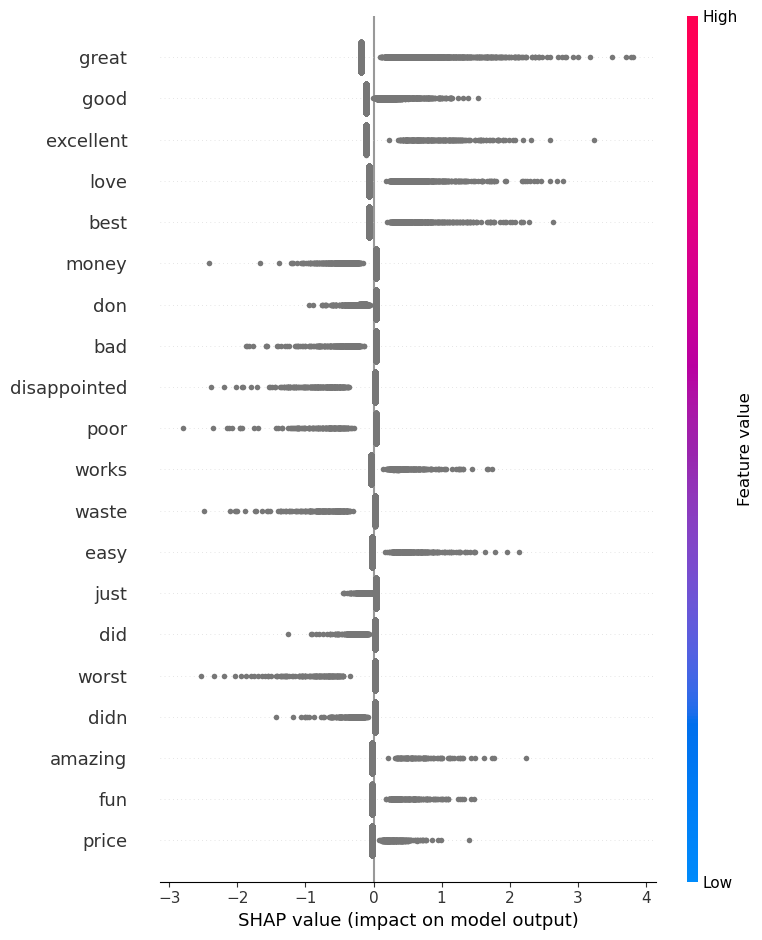

In [91]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=True)
plt.savefig("shap_summary.png", bbox_inches='tight')
plt.close()

The plot shows that words on the right side contribute to positive predictions, while words on the left side are associated with negative classifications. Furthermore, the higher a word is positioned, the greater its overall impact on the model’s decision.

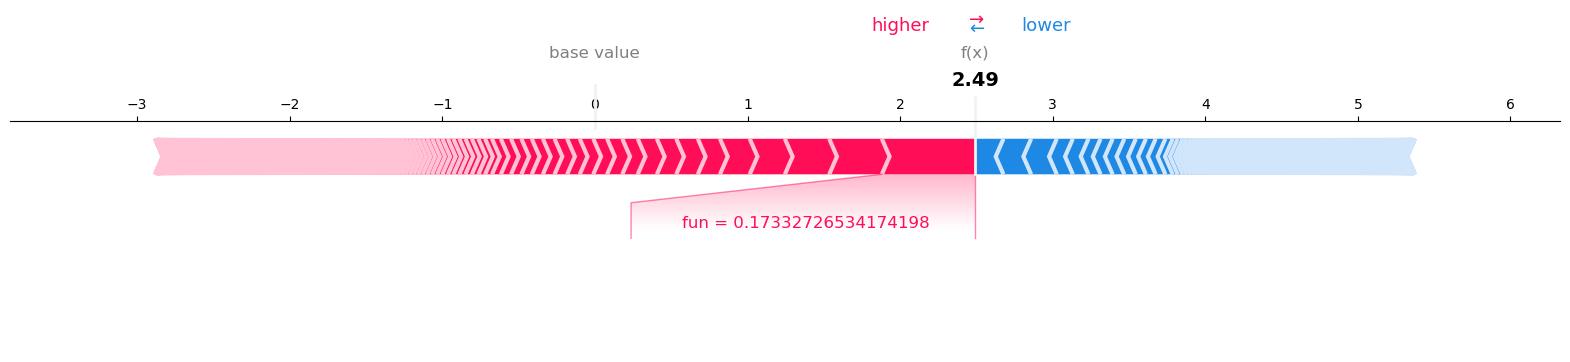

In [88]:
index = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test_transformed[index].toarray(),
    feature_names=feature_names,
    matplotlib=True
)



The SHAP force plot provides a local explanation of an individual prediction by showing how each feature contributes to the final output.

Red features push the prediction towards the positive class, while blue features push it towards the negative class.

In this example, the model predicts a positive sentiment with high confidence (logit = 2.49, ~92% probability). This indicates that positive terms in the text have a stronger influence than negative ones, leading to a confident classification.

This analysis helps improve model transparency and trust by identifying which words drive predictions.